# Adult Census Income: базовая очистка данных

В этом notebook выполняются первые этапы подготовки датасета:

1. Удаление лишних пробелов в строковых значениях.
2. Замена `?` на `NaN`.
3. Очистка целевой переменной `income` от точки в конце значения.
4. Анализ пропусков.

Feature engineering, train/test split и обучение моделей будут вынесены в отдельные этапы.

## Загрузка данных

В исходных файлах Adult Census Income нет строки с названиями колонок, поэтому задаём имена признаков вручную. Файл `adult.test` содержит служебную первую строку, её пропускаем при чтении.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

In [2]:
columns = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education_num",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "native_country",
    "income",
]

train_path = "../data/adult.data"
test_path = "../data/adult.test"

train_raw = pd.read_csv(train_path, header=None, names=columns)
test_raw = pd.read_csv(test_path, header=None, names=columns, skiprows=1)

df = pd.concat([train_raw, test_raw], ignore_index=True)

print("Train shape:", train_raw.shape)
print("Test shape:", test_raw.shape)
print("Combined shape:", df.shape)

df.head()

Train shape: (32561, 15)
Test shape: (16281, 15)
Combined shape: (48842, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 1. Удаление лишних пробелов

В исходных CSV-файлах значения после запятых часто содержат пробел в начале. Например, вместо `Private` встречается ` Private`. Для категориальных признаков это важно: строки с лишним пробелом и без него считаются разными категориями.

In [3]:
string_columns = df.select_dtypes(include="object").columns

for column in string_columns:
    df[column] = df[column].str.strip()

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 2. Замена `?` на `NaN`

В Adult Census Income пропуски записаны не как пустые значения, а как строка `?`. Заменим такие значения на `NaN`, чтобы дальше с ними могли работать стандартные инструменты `pandas` и `sklearn`.

In [4]:
df = df.replace("?", np.nan)

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 3. Очистка целевой переменной

В `adult.data` значения целевой переменной записаны как `<=50K` и `>50K`, а в `adult.test` как `<=50K.` и `>50K.`. Уберём точку, чтобы классы были записаны одинаково.

In [5]:
df["income"] = df["income"].str.replace(".", "", regex=False)

df["income"].value_counts()

income
<=50K    37155
>50K     11687
Name: count, dtype: int64

## 4. Анализ пропусков

Теперь можно посмотреть, в каких признаках есть пропущенные значения и насколько их много.

In [6]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100,
})

missing_summary = missing_summary[missing_summary["missing_count"] > 0]
missing_summary = missing_summary.sort_values("missing_count", ascending=False)

missing_summary

,missing_count,missing_percent
occupation,2809,5.751198
workclass,2799,5.730724
native_country,857,1.754637


In [7]:
rows_with_missing = df.isna().any(axis=1).sum()
rows_with_missing_percent = rows_with_missing / len(df) * 100

print("Rows with at least one missing value:", rows_with_missing)
print("Percent of rows with missing values:", round(rows_with_missing_percent, 2))

Rows with at least one missing value: 3620
Percent of rows with missing values: 7.41


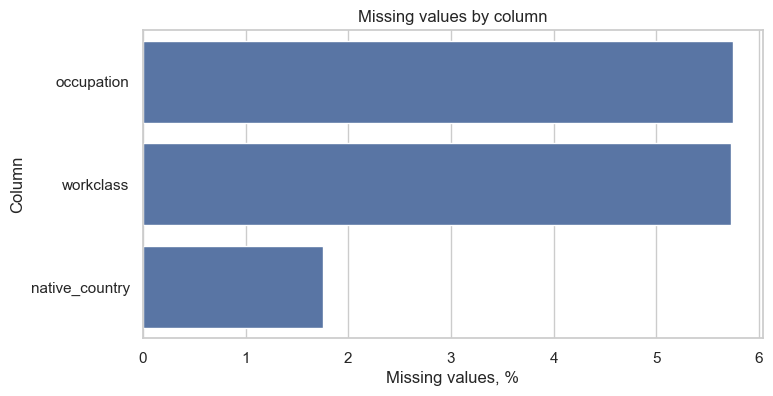

In [8]:
missing_plot = missing_summary.reset_index().rename(columns={"index": "column"})

plt.figure(figsize=(8, 4))
sns.barplot(data=missing_plot, x="missing_percent", y="column")
plt.title("Missing values by column")
plt.xlabel("Missing values, %")
plt.ylabel("Column")
plt.show()

### Вывод по пропускам

Пропуски в Adult Census Income находятся в категориальных признаках: `workclass`, `occupation` и `native_country`.

Пока выбираем стратегию заполнения отдельной категорией `Unknown`. Это честный вариант для данного датасета: мы не пытаемся угадать неизвестную категорию, а сохраняем сам факт отсутствия значения.

Позже эту стратегию можно сравнить с другими подходами через cross-validation:

- удаление строк с пропусками;
- заполнение самой частой категорией;
- заполнение по группам.

Важно: в финальном ML-пайплайне заполнение пропусков нужно делать внутри `sklearn Pipeline`, чтобы preprocessing обучался только на train set и не создавал leakage.

In [9]:
df_unknown = df.fillna("Unknown")

df_unknown[["workclass", "occupation", "native_country"]].isna().sum()

workclass         0
occupation        0
native_country    0
dtype: int64

## 5. Анализ дубликатов

После базовой очистки проверим полные дубликаты. Полный дубликат означает, что совпадают все признаки и целевая переменная.

In [10]:
duplicate_count = df.duplicated().sum()
duplicate_percent = duplicate_count / len(df) * 100

print("Full duplicate rows:", duplicate_count)
print("Duplicate rows, %:", round(duplicate_percent, 3))

Full duplicate rows: 52
Duplicate rows, %: 0.106


In [11]:
df[df.duplicated(keep=False)].sort_values(columns).head(10)

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
24667,17,Private,153021,12th,8,Never-married,Sales,Own-child,White,Female,0,0,20,United-States,<=50K
36713,17,Private,153021,12th,8,Never-married,Sales,Own-child,White,Female,0,0,20,United-States,<=50K
36461,18,Self-emp-inc,378036,12th,8,Never-married,Farming-fishing,Own-child,White,Male,0,0,10,United-States,<=50K
48521,18,Self-emp-inc,378036,12th,8,Never-married,Farming-fishing,Own-child,White,Male,0,0,10,United-States,<=50K
17673,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
18698,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
3118,19,Private,130431,5th-6th,3,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,36,Mexico,<=50K
34229,19,Private,130431,5th-6th,3,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,36,Mexico,<=50K
6990,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K
21318,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K


### Решение по дубликатам

Полные дубликаты удаляем до train/test split.

Причина: если оставить одинаковые строки, одна и та же запись может оказаться одновременно в train и test. Это может немного завысить финальную оценку качества модели.

Удаляем только полные дубликаты. Похожие строки не трогаем, потому что разные люди могут иметь одинаковые значения части признаков.

In [12]:
df_clean = df.drop_duplicates().reset_index(drop=True)

print("Rows before removing duplicates:", len(df))
print("Rows after removing duplicates:", len(df_clean))

Rows before removing duplicates: 48842
Rows after removing duplicates: 48790
